**Lab 5: Slide Image Processing**

In this lab, we'll use two computer vision algorithms to detect an outcome of interest (in this case red blood cell count in urine) and perform categorical analysis. We will then manually evaluate the performance of the of the detection algorithms.

**Step 1:** First, choose one of the images and load it.

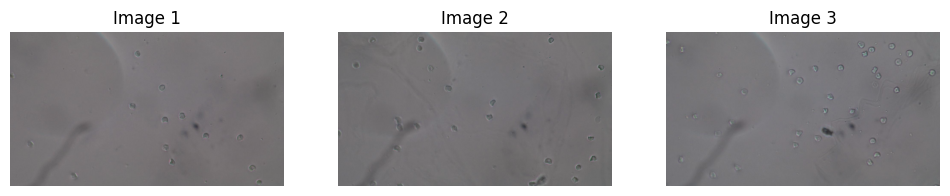

In [41]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

# from google.colab.patches import cv2_imshow

img = cv2.imread('img1.jpg')

imgs = []
plt.figure(figsize=(12, 6))
for i in range(1, 4):
    img = cv2.imread(f'img{i}.jpg')
    imgs.append(img)
    plt.subplot(1, 3, i)
    plt.title(f"Image {i}")
    plt.imshow(img)
    plt.axis('off')

In [ ]:
def hough(img, idx):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray_blurred = cv2.medianBlur(gray, 5)
    
    circles = cv2.HoughCircles(
        gray_blurred, 
        cv2.HOUGH_GRADIENT, 
        dp=1.2,
        minDist=40,      
        param1=50,       
        param2=5,
        minRadius=15,    
        maxRadius=15     
    )

    output = img.copy() 

    if circles is not None:
        circles = np.uint16(np.around(circles))
        for i in circles[0, :]:
            cv2.circle(output, (i[0], i[1]), i[2], (0, 255, 0), 2)
    print(len(circles[0, :]))

    plt.figure(figsize=(12, 6))
    idx += 1
    plt.subplot(1, 2, 1)
    plt.title(f"Image {idx} - Blurred")
    plt.imshow(gray_blurred, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title(f"Image {idx} - Detected Cells")
    plt.imshow(output)
    plt.axis('off')
    
    plt.show()
    
def canny(img, idx):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 40, 50)
    
    kernel = np.ones((3,3), np.uint8)
    edges = cv2.dilate(edges, kernel, iterations=2)
    edges = cv2.erode(edges, kernel, iterations=1)

    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    min_area = 280 
    max_area = 1000
    final_contours = [cnt for cnt in contours if min_area < cv2.contourArea(cnt) < max_area]
    
    output_img = img.copy()
    cv2.drawContours(output_img, final_contours, -1, (0, 255, 0), 2)
    
    cell_count = len(final_contours)
    print(cell_count)
    
    plt.figure(figsize=(12, 6))
    idx += 1
    plt.subplot(1, 2, 1)
    plt.title(f"Image {idx} - Original")
    plt.imshow(img)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title(f"Image {idx} - Detected Cells")
    plt.imshow(output_img)
    plt.axis('off')
    plt.show()

**Step 2:** Perform the Hough Circle function to count the number of red blood cells present in the image. Make sure to fine tune the parameters and report the final results, including a figure of the urine slide image with all identified Hough Circle overlay. Ideally you should be able to identify all cells in the figure without any false positives.

14


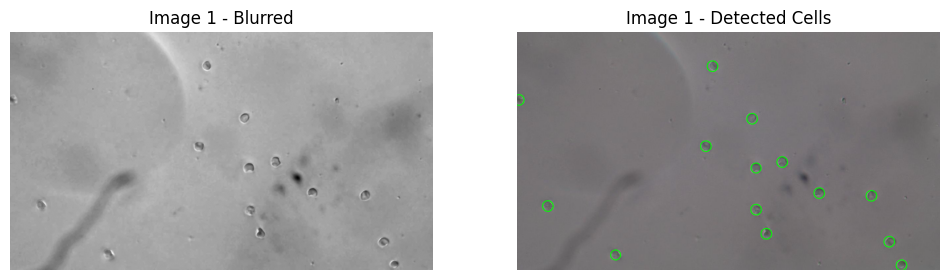

In [25]:
hough(imgs[0], 0)

**Step 3:** Next, perform edge detection/contouring with the Canny function and count the number of RBCs as the number of contour groups. Fine tune the parameters and report the final results, including a figure of the urine slide image with all identified contour groups. You should be able to identify all cells in the figure without any false positives.

14


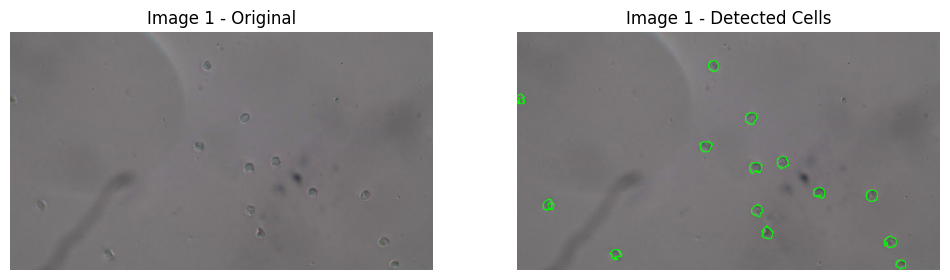

In [26]:
canny(imgs[0], 0)

Now, load another image and use it to test the performance of your algorithms.

**Step 4:** Count RBCs with your tuned Hough Circle algorithm. Show the figure with the Hough Circle overlay. Report precision and recall on the test image and discuss what the results mean.

If you are unfamiliar with the terms "precision" and "recall", simply speaking precision is the ratio between the **correctly predicted cells** and the number of **all predicted results (True Positive + False Positive)**, recall is the ratio between the **correctly predicted cells (True Positive)** and the **actual number of cells (True Positive + False Negative)** in the figure.

28


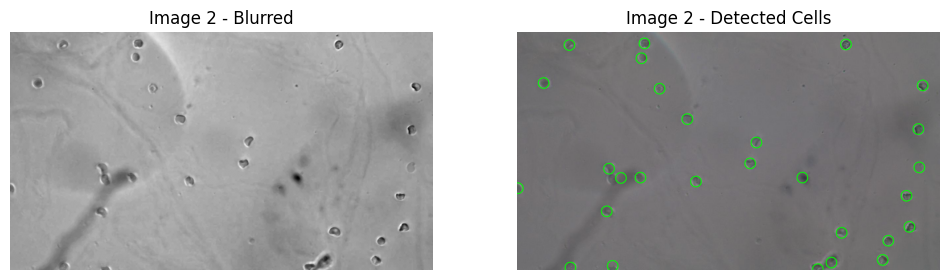

In [27]:
hough(imgs[1], 1)

In [34]:
TP = 27
FP = 1
FN = 0
accuracy = TP / (TP + FP + FN) if (TP + FP + FN) > 0 else 0
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

Accuracy: 0.96
Precision: 0.96
Recall: 1.00


**Step 5:** Count RBCs with your tuned Canny algorithm. Show the figure with the edge contour overlay. Report precision and recall on the test image and discuss what the results mean.

19


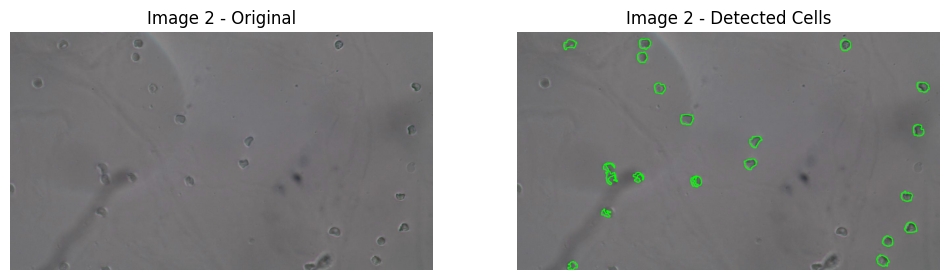

In [29]:
canny(imgs[1], 1)

In [35]:
TP = 20
FP = 0
FN = 7
accuracy = TP / (TP + FP + FN) if (TP + FP + FN) > 0 else 0
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

Accuracy: 0.74
Precision: 1.00
Recall: 0.74
